In [62]:
import os
import sys
import numpy as np
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
data = {
    "choice": {
        "PO": {
            "Linear": [0.64815, 0.62602, 0.77778, 0.73770, 0.86290, 0.90625, 0.70909, 0.77852, 0.79348, 0.84158],
            "RRR": [0.68519, 0.69106, 0.80556, 0.73770, 0.84677, 0.92188, 0.72727, 0.83893, 0.77174, 0.89109],
            "MLP": [0.61111, 0.64228, 0.80556, 0.75410, 0.90323, 0.87500, 0.65455, 0.81879, 0.72826, 0.87129],
            "RRR (MS)": [0.75926, 0.64228, 0.81944, 0.74590, 0.91935, 0.91406, 0.76364, 0.87248, 0.76087, 0.90099],
            "RRR (MR)": [0.77778, 0.71545, 0.83333, 0.81967, 0.92742, 0.92969, 0.78182, 0.86577, 0.78261, 0.91089],
            "BMMHMM": [0.64815, 0.65854, 0.76389, 0.73770, 0.89516, 0.92188, 0.74545, 0.85235, 0.79348, 0.84158],
            "BMMHMM (MS)": [0.62963, 0.65854, 0.76389, 0.74590, 0.86290, 0.92969, 0.74545, 0.85906, 0.79348, 0.80198],
            "combined": [0.75926, 0.71545, 0.84722, 0.82787, 0.92742, 0.93750, 0.78182, 0.86577, 0.78261, 0.88119],
        },
        "LP": {
            "Linear": [0.62963, 0.60163, 0.73611, 0.72131, 0.75806, 0.85156, 0.72727, 0.55034, 0.78261, 0.67327],
            "RRR": [0.64815, 0.58537, 0.73611, 0.77869, 0.82258, 0.83594, 0.80000, 0.67114, 0.78261, 0.73267],
            "MLP": [0.61111, 0.56098, 0.77778, 0.80328, 0.84677, 0.75781, 0.69091, 0.62416, 0.79348, 0.74257],
            "RRR (MS)": [0.72222, 0.65041, 0.81944, 0.73770, 0.70161, 0.82258, 0.81818, 0.65101, 0.77174, 0.82178],
            "RRR (MR)": [0.72222, 0.67480, 0.81944, 0.78689, 0.82258, 0.84375, 0.82031, 0.69799, 0.79348, 0.79208],
            "BMMHMM": [0.64815, 0.56911, 0.73611, 0.75410, 0.80645, 0.88281, 0.81818, 0.57718, 0.79348, 0.73267],
            "BMMHMM (MS)": [0.61111, 0.60976, 0.75000, 0.73770, 0.79839, 0.90625, 0.85455, 0.58389, 0.79348, 0.71287],
            "combined": [0.70370, 0.67480, 0.87500, 0.74590, 0.86290, 0.89063, 0.85455, 0.75839, 0.77174, 0.82178],
        },
        "DG": {
            "Linear": [0.53704, 0.48780, 0.61111, 0.41803, 0.73387, 0.67188, 0.60000, 0.62416, 0.78261, 0.64356],
            "RRR": [0.61111, 0.46341, 0.63889, 0.54918, 0.69355, 0.67969, 0.67273, 0.65772, 0.80435, 0.67327],
            "MLP": [0.55556, 0.44715, 0.70833, 0.38525, 0.71774, 0.62500, 0.67273, 0.63758, 0.79348, 0.60396],
            "RRR (MS)": [0.61111, 0.65041, 0.72222, 0.60656, 0.79032, 0.65625, 0.65455, 0.65101, 0.76087, 0.61386],
            "RRR (MR)": [0.66667, 0.65041, 0.72222, 0.55738, 0.74194, 0.71875, 0.67273, 0.70470, 0.77174, 0.66337],
            "BMMHMM": [0.61111, 0.49593, 0.73611, 0.58197, 0.81452, 0.67188, 0.72727, 0.62416, 0.79348, 0.66337],
            "BMMHMM (MS)": [0.61111, 0.60976, 0.70833, 0.51639, 0.85484, 0.71094, 0.72727, 0.58389, 0.78261, 0.74257],
            "combined": [0.61111, 0.65041, 0.75000, 0.58197, 0.80645, 0.68750, 0.70909, 0.77181, 0.80435, 0.69307],
        },
        "CA1": {
            "Linear": [0.61111, 0.53659, 0.65278, 0.58197, 0.67742, 0.66406, 0.65455, 0.60403, 0.78261, 0.55446],
            "RRR": [0.61111, 0.60976, 0.70833, 0.58197, 0.67742, 0.67188, 0.69091, 0.61074, 0.79348, 0.61386],
            "MLP": [0.59259, 0.48780, 0.65278, 0.57377, 0.65323, 0.67188, 0.65455, 0.59732, 0.79348, 0.44554],
            "RRR (MS)": [0.6111111111, 0.61789, 0.72222, 0.59836, 0.66935, 0.78906, 0.76364, 0.63087, 0.80435, 0.61386],
            "RRR (MR)": [0.72222, 0.53659, 0.70833, 0.59016, 0.69355, 0.80469, 0.78182, 0.71812, 0.79348, 0.57426],
            "BMMHMM": [0.61111, 0.59350, 0.70833, 0.57377, 0.62097, 0.71875, 0.70909, 0.65101, 0.79348, 0.61386],
            "BMMHMM (MS)": [0.61111, 0.63415, 0.70833, 0.57377, 0.72581, 0.77344, 0.76364, 0.63087, 0.79348, 0.61386],
            "combined": [0.62963, 0.61789, 0.72222, 0.61475, 0.71774, 0.75781, 0.81818, 0.65772, 0.80435, 0.62376],
        },
        "VISa": {
            "Linear": [0.62963, 0.76423, 0.68056, 0.63115, 0.73387, 0.78906, 0.65455, 0.72483, 0.77174, 0.69307],
            "RRR": [0.66667, 0.82114, 0.70833, 0.64754, 0.81452, 0.76613, 0.70909, 0.73154, 0.76087, 0.70297],
            "MLP": [0.61111, 0.78049, 0.59722, 0.64754, 0.83871, 0.76563, 0.65455, 0.70470, 0.77174, 0.64356],
            "RRR (MS)": [0.72222, 0.83740, 0.75000, 0.69672, 0.84375, 0.82813, 0.81818, 0.71141, 0.80435, 0.68317],
            "RRR (MR)": [0.75926, 0.81301, 0.69444, 0.67213, 0.81452, 0.83594, 0.78182, 0.71812, 0.81522, 0.73267],
            "BMMHMM": [0.72222, 0.71545, 0.72222, 0.68033, 0.76613, 0.84375, 0.81818, 0.77852, 0.79348, 0.72277],
            "BMMHMM (MS)": [0.72222, 0.75610, 0.70833, 0.63934, 0.76613, 0.82813, 0.81818, 0.73154, 0.79348, 0.77228],
            "combined": [0.74074, 0.82927, 0.76389, 0.68033, 0.84375, 0.87500, 0.83636, 0.78523, 0.80435, 0.73267],
        },
    },
    "prior": {
        "PO": {
            "Linear": [0.51477, 0.17940, 0.48120, 0.42274, 0.55298, 0.50501, 0.30630, 0.45771, 0.49878, 0.66603],
            "RRR": [0.51071, 0.20363, 0.53497, 0.36973, 0.51704, 0.51720, 0.43016, 0.50278, 0.66614, 0.65957],
            "MLP": [0.53469, 0.13941, 0.49578, 0.44493, 0.63367, 0.54053, 0.27265, 0.45748, 0.51507, 0.63827],
            "RRR (MS)": [0.49909, 0.30474, 0.54463, 0.51102, 0.67252, 0.53518, 0.45043, 0.60520, 0.68968, 0.69030],
            "RRR (MR)": [0.49351, 0.15962, 0.41491, 0.50951, 0.67949, 0.55682, 0.49919, 0.56073, 0.63633, 0.69809],
            "LGAR1": [0.58789, 0.27566, 0.78897, 0.76520, 0.79389, 0.69818, 0.40965, 0.78829, 0.75013, 0.79172],
            "LGAR1 (MS)": [0.58218, 0.28674, 0.83371, 0.77320, 0.81043, 0.75833, 0.41429, 0.79299, 0.75053, 0.81943],
            "combined": [0.66600, 0.39754, 0.84411, 0.77226, 0.82134, 0.72689, 0.45000, 0.79793, 0.76464, 0.79529],
        },
        "LP": {
            "Linear": [0.03302, 0.18512, 0.41803, 0.32965, 0.55529, 0.46155, 0.29356, 0.18038, 0.41743, 0.22082],
            "RRR": [0.21532, 0.30928, 0.48968, 0.43080, 0.50783, 0.44201, 0.42908, 0.35968, 0.42054, 0.34175],
            "MLP": [-0.10654, 0.23122, 0.26170, 0.35450, 0.51524, 0.53298, 0.35469, 0.14645, 0.39306, 0.38924],
            "RRR (MS)": [0.16291, 0.35148, 0.53278, 0.47501, 0.55928, 0.48036, 0.31668, 0.36582, 0.36895, 0.46888],
            "RRR (MR)": [0.12350, 0.35376, 0.50437, 0.47676, 0.50455, 0.45851, 0.38492, 0.39066, 0.42159, 0.45044],
            "LGAR1": [0.25259, 0.35687, 0.73183, 0.73456, 0.76387, 0.70149, 0.64620, 0.37459, 0.84009, 0.55216],
            "LGAR1 (MS)": [0.55135, 0.38034, 0.77038, 0.72465, 0.82290, 0.77384, 0.65188, 0.40655, 0.86527, 0.56944],
            "combined": [0.54039, 0.54294, 0.80702, 0.68300, 0.86099, 0.76311, 0.67340, 0.45445, 0.85605, 0.66904],
        },
        "DG": {
            "Linear": [0.10822, 0.29502, 0.23494, 0.03749, 0.35445, 0.45286, 0.07656, 0.35694, 0.20312, 0.30238],
            "RRR": [0.02568, 0.45014, 0.30162, 0.16903, 0.36207, 0.33017, 0.25438, 0.56074, 0.53155, 0.33842],
            "MLP": [-0.07764, 0.24693, 0.31729, -0.04675, 0.22666, 0.37369, 0.07587, 0.39606, 0.28034, 0.22067],
            "RRR (MS)": [0.30877, 0.52402, 0.27055, 0.26201, 0.44822, 0.33922, 0.53241, 0.53021, 0.50175, 0.37093],
            "RRR (MR)": [0.31513, 0.41000, 0.37046, 0.25206, 0.34938, 0.33760, 0.59527, 0.38270, 0.53810, 0.35685],
            "LGAR1": [0.11050, 0.29829, 0.28714, 0.18473, 0.50640, 0.63921, 0.17996, 0.59509, 0.62074, 0.51949],
            "LGAR1 (MS)": [0.11451, 0.34931, 0.67271, 0.15134, 0.61303, 0.71807, 0.20097, 0.56162, 0.64758, 0.53075],
            "combined": [0.31854, 0.55550, 0.56594, 0.34782, 0.62709, 0.78007, 0.47115, 0.67840, 0.75990, 0.50137],
        },
        "CA1": {
            "Linear": [0.10852, 0.09048, 0.25790, 0.16887, 0.47479, 0.38536, 0.04722, 0.35991, 0.30386, 0.19267],
            "RRR": [-0.07101, 0.37251, 0.52204, 0.33996, 0.50223, 0.41770, 0.26415, 0.55566, 0.36333, 0.25531],
            "MLP": [0.06368, 0.22814, 0.40156, 0.19459, 0.54007, 0.23464, 0.15965, 0.42582, 0.23356, -0.06247],
            "RRR (MS)": [0.15434, 0.43195, 0.63171, 0.31569, 0.52439, 0.46306, 0.44515, 0.54245, 0.57583, 0.32201],
            "RRR (MR)": [0.00763, 0.29967, 0.58941, 0.31836, 0.41009, 0.41909, 0.43134, 0.52721, 0.53279, 0.24167],
            "LGAR1": [0.08902, 0.15994, 0.40691, 0.28944, 0.59572, 0.62238, 0.32802, 0.68897, 0.72125, 0.36622],
            "LGAR1 (MS)": [0.16590, 0.15884, 0.41223, 0.32810, 0.69340, 0.65424, 0.37640, 0.72243, 0.72495, 0.41458],
            "combined": [0.24878, 0.45734, 0.63336, 0.46923, 0.71166, 0.66881, 0.53530, 0.67785, 0.77370, 0.47077],
        },
        "VISa": {
            "Linear": [0.09785, 0.43508, 0.27228, 0.01008, 0.37997, 0.41009, 0.32323, 0.63729, 0.45040, 0.22139],
            "RRR": [0.42451, 0.56393, 0.42732, 0.13894, 0.44485, 0.40041, 0.46707, 0.64297, 0.66050, 0.38432],
            "MLP": [0.03575, 0.47145, 0.16771, 0.18096, 0.46361, 0.34110, 0.29299, 0.52100, 0.54800, 0.30622],
            "RRR (MS)": [0.47614, 0.66380, 0.53214, 0.23264, 0.55771, 0.38738, 0.47140, 0.73350, 0.72600, 0.45618],
            "RRR (MR)": [0.37560, 0.63634, 0.48931, 0.12865, 0.51759, 0.29830, 0.44944, 0.64276, 0.69928, 0.38549],
            "LGAR1": [0.18810, 0.70383, 0.54539, 0.00280, 0.63946, 0.62631, 0.45439, 0.68451, 0.77872, 0.72101],
            "LGAR1 (MS)": [0.42651, 0.73279, 0.54779, 0.02231, 0.67413, 0.64783, 0.46605, 0.70747, 0.79260, 0.72635],
            "combined": [0.56269, 0.76461, 0.58412, 0.32343, 0.70319, 0.56513, 0.50621, 0.74961, 0.83229, 0.77020],
        },
    },
    "wheel": {
        "PO": {
            "Linear": [0.38561, 0.40145, 0.59440, 0.42121, 0.49936, 0.60010, 0.54421, 0.43112, 0.40787, 0.51835],
            "RRR": [0.45569, 0.40415, 0.59176, 0.45242, 0.53214, 0.57325, 0.56466, 0.47508, 0.45041, 0.55051],
            "MLP": [0.41905, 0.42200, 0.59419, 0.54657, 0.58293, 0.54767, 0.51241, 0.45860, 0.47721, 0.57099],
            "RRR (MS)": [0.48419, 0.42914, 0.61912, 0.47249, 0.53504, 0.60848, 0.62687, 0.51004, 0.46858, 0.58448],
            "RRR (MR)": [0.47120, 0.41740, 0.60483, 0.46375, 0.53410, 0.59410, 0.59423, 0.49320, 0.45990, 0.56800],
        },
        "LP": {
            "Linear": [0.35886, 0.32731, 0.53753, 0.38965, 0.31907, 0.57627, 0.58834, 0.39472, 0.38188, 0.47219],
            "RRR": [0.40796, 0.33903, 0.53344, 0.40822, 0.43324, 0.59967, 0.60277, 0.39570, 0.41930, 0.48582],
            "MLP": [0.30005, 0.33413, 0.55597, 0.42547, 0.43910, 0.60702, 0.56717, 0.39359, 0.44306, 0.53205],
            "RRR (MS)": [0.43358, 0.34528, 0.56778, 0.43286, 0.43500, 0.54698, 0.63342, 0.42201, 0.44392, 0.58725],
            "RRR (MR)": [0.42072, 0.34216, 0.55234, 0.42945, 0.43612, 0.57780, 0.58963, 0.40936, 0.43117, 0.53493],
        },
        "DG": {
            "Linear": [0.26007, 0.36439, 0.45614, 0.26347, 0.43412, 0.54326, 0.52194, 0.43844, 0.34424, 0.45285],
            "RRR": [0.26929, 0.38536, 0.44242, 0.29363, 0.41767, 0.51827, 0.53095, 0.46323, 0.38821, 0.47488],
            "MLP": [0.24088, 0.33815, 0.48054, 0.31312, 0.42668, 0.52541, 0.55593, 0.41100, 0.32279, 0.46834],
            "RRR (MS)": [0.33400, 0.39362, 0.54029, 0.31914, 0.44798, 0.60427, 0.60993, 0.42602, 0.37370, 0.49086],
            "RRR (MR)": [0.30325, 0.38911, 0.46576, 0.31642, 0.43780, 0.55562, 0.56104, 0.44472, 0.36657, 0.47841],
        },
        "CA1": {
            "Linear": [0.29767, 0.36963, 0.41465, 0.26964, 0.41334, 0.49737, 0.53362, 0.44861, 0.39525, 0.42737],
            "RRR": [0.32743, 0.37056, 0.45119, 0.26347, 0.43754, 0.61406, 0.59473, 0.45753, 0.40276, 0.48783],
            "MLP": [0.28596, 0.38593, 0.45876, 0.23540, 0.43340, 0.58240, 0.57305, 0.43640, 0.38093, 0.51383],
            "RRR (MS)": [0.40559, 0.39362, 0.51367, 0.31904, 0.45714, 0.58274, 0.59701, 0.46961, 0.40833, 0.56764],
            "RRR (MR)": [0.35287, 0.37802, 0.47592, 0.29701, 0.44561, 0.58332, 0.58520, 0.45592, 0.40034, 0.51876],
        },
        "VISa": {
            "Linear": [0.39994, 0.46187, 0.36695, 0.35903, 0.42575, 0.59952, 0.61915, 0.37962, 0.47573, 0.48477],
            "RRR": [0.43792, 0.46539, 0.39252, 0.40145, 0.43554, 0.59482, 0.65524, 0.38666, 0.50174, 0.53364],
            "MLP": [0.38269, 0.46958, 0.38675, 0.34869, 0.38392, 0.58176, 0.64189, 0.35780, 0.49101, 0.55278],
            "RRR (MS)": [0.48224, 0.47168, 0.43349, 0.37427, 0.44940, 0.60207, 0.66658, 0.36810, 0.49520, 0.57141],
            "RRR (MR)": [0.46013, 0.47023, 0.41384, 0.38896, 0.44267, 0.59830, 0.66043, 0.37721, 0.48837, 0.54726],
        },
    },
    "whisker": {
        "PO": {
            "Linear": [0.44040, 0.58726, 0.47389, 0.47860, 0.60909, 0.52849, 0.21614, 0.31513, 0.39594, 0.45424],
            "RRR": [0.53890, 0.60694, 0.47739, 0.51562, 0.62825, 0.54839, 0.25688, 0.34794, 0.45759, 0.46284],
            "MLP": [0.54294, 0.62929, 0.45292, 0.53582, 0.65337, 0.55366, 0.22376, 0.37992, 0.47374, 0.46960],
            "RRR (MS)": [0.59039, 0.61006, 0.52025, 0.51929, 0.64058, 0.54627, 0.26533, 0.36528, 0.46934, 0.47721],
            "RRR (MR)": [0.56547, 0.60942, 0.49372, 0.51719, 0.64116, 0.54703, 0.25897, 0.35691, 0.46332, 0.47109],
        },
        "LP": {
            "Linear": [0.40372, 0.52213, 0.45072, 0.40470, 0.49254, 0.53758, 0.22771, 0.35089, 0.38192, 0.35411],
            "RRR": [0.44757, 0.51204, 0.47371, 0.42340, 0.51888, 0.53763, 0.23051, 0.35516, 0.42189, 0.40282],
            "MLP": [0.41740, 0.51561, 0.44051, 0.43909, 0.54164, 0.57048, 0.22171, 0.37473, 0.48081, 0.37496],
            "RRR (MS)": [0.48229, 0.51093, 0.47000, 0.45122, 0.52500, 0.54896, 0.29370, 0.36139, 0.44989, 0.42480],
            "RRR (MR)": [0.46803, 0.51382, 0.46176, 0.43280, 0.53132, 0.54392, 0.25748, 0.35722, 0.43677, 0.41352],
        },
        "DG": {
            "Linear": [0.34386, 0.57342, 0.37175, 0.35728, 0.53079, 0.49585, 0.18585, 0.34029, 0.44961, 0.31293],
            "RRR": [0.35093, 0.61524, 0.38205, 0.38689, 0.57406, 0.50784, 0.19856, 0.36780, 0.48964, 0.32708],
            "MLP": [0.36490, 0.62335, 0.45380, 0.39328, 0.62812, 0.48829, 0.21711, 0.37093, 0.54005, 0.27865],
            "RRR (MS)": [0.46482, 0.60533, 0.44709, 0.39701, 0.57873, 0.51212, 0.27256, 0.35664, 0.51792, 0.33963],
            "RRR (MR)": [0.40766, 0.61042, 0.41893, 0.39143, 0.60147, 0.50319, 0.24685, 0.36218, 0.50487, 0.33346],
        },
        "CA1": {
            "Linear": [0.40623, 0.57830, 0.37393, 0.34594, 0.54811, 0.59186, 0.22048, 0.35611, 0.45335, 0.33468],
            "RRR": [0.45872, 0.58585, 0.38928, 0.36273, 0.58660, 0.60233, 0.24762, 0.36322, 0.51687, 0.35349],
            "MLP": [0.47646, 0.63577, 0.43034, 0.38247, 0.62057, 0.60936, 0.23980, 0.36726, 0.52820, 0.35103],
            "RRR (MS)": [0.50472, 0.60374, 0.47381, 0.37908, 0.61321, 0.60983, 0.31060, 0.37541, 0.51882, 0.37433],
            "RRR (MR)": [0.48623, 0.59701, 0.44532, 0.37345, 0.61697, 0.60657, 0.27856, 0.36951, 0.52216, 0.36349],
        },
        "VISa": {
            "Linear": [0.51422, 0.65596, 0.32394, 0.30850, 0.54185, 0.57404, 0.26427, 0.35301, 0.52228, 0.33544],
            "RRR": [0.53275, 0.65561, 0.35197, 0.35845, 0.58159, 0.56452, 0.28275, 0.35412, 0.53981, 0.33106],
            "MLP": [0.52701, 0.68871, 0.31301, 0.38410, 0.58857, 0.59525, 0.29751, 0.38591, 0.55227, 0.29252],
            "RRR (MS)": [0.57257, 0.66317, 0.38707, 0.34103, 0.59782, 0.57666, 0.33743, 0.35339, 0.55586, 0.38226],
            "RRR (MR)": [0.55632, 0.66701, 0.37493, 0.35856, 0.59493, 0.57743, 0.31689, 0.36991, 0.54692, 0.35831],
        },
    }
}

/burg/home/yz4123/.conda/envs/decoding/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "orientation" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/burg/home/yz4123/.conda/envs/decoding/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "facecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/burg/home/yz4123/.conda/envs/decoding/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "edgecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/burg/home/yz4123/.conda/envs/decoding/lib/python3.11

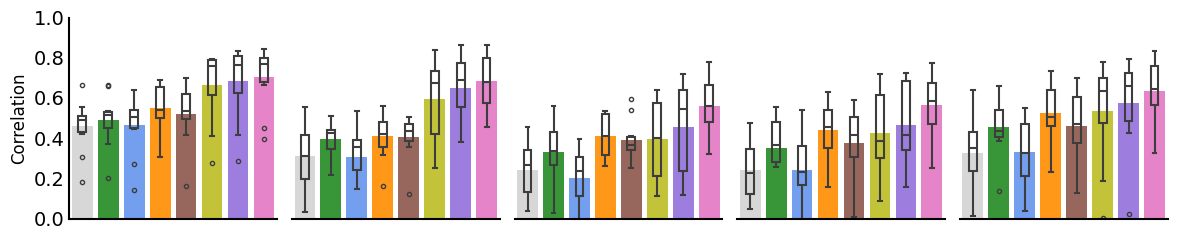

In [15]:
colors = ['lightgray', 'forestgreen', 'cornflowerblue', 'darkorange', 'tab:brown', 'tab:olive', 'mediumpurple', 'tab:pink']
methods = ['Linear', 'RRR', 'MLP', 'RRR (MS)', 'RRR (MR)', 'BMMHMM', 'BMMHMM (MS)', 'combined']

fig, axes = plt.subplots(1, 5, figsize=(12, 2.5), sharey=True, sharex=False)

beh = 'prior'

for ax, (title, values) in zip(axes, data[beh].items()):
    num_bars = len(values)
    x = np.arange(num_bars)

    # Bar plot
    if beh in ['choice', 'prior']:
        bar_width = 0.8
        box_width = 0.3
    else:
        bar_width = 0.68
        box_width = 0.23

    ax.bar(x, np.mean(list(values.values()), axis=1), width=bar_width, capsize=5, color=colors[:num_bars], alpha=0.9, label=methods[:num_bars])
    
    # Box plot overlay
    box_data = list(values.values())
    sns.boxplot(data=box_data, ax=ax, width=box_width, linewidth=1.5, fliersize=3, whis=1.5, boxprops={'facecolor': 'none'})

    # ax.set_title(title, fontsize=14)
    ax.set_xticks(x)

    ax.set_xticklabels([])

    ax.tick_params(axis='x', labelsize=8)
    ax.tick_params(axis='y', labelsize=14)

    if beh == 'choice':
        ax.set_ylabel('Accuracy', fontsize=12)
        ax.set_ylim(0.35, 1.0)
    elif beh == 'prior':
        ax.set_ylabel('Correlation', fontsize=12)
        ax.set_ylim(0., 1)
    elif beh == 'wheel':
        ax.set_ylabel(r'$R^2$', fontsize=12)
        ax.set_ylim(0.2, 0.7)
        ax.set_xlim(-1, 5)
    elif beh == 'whisker':
        ax.set_ylabel(r'$R^2$', fontsize=12)
        ax.set_ylim(0.15, 0.75)
        ax.set_xlim(-1, 5)

    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
        ax.tick_params(axis='x', width=1.5, length=0)
        ax.tick_params(axis='y', width=1.5, length=0)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    if title != 'PO':
        ax.spines['left'].set_visible(False)

plt.tight_layout()
# plt.savefig(f'/burg/stats/users/yz4123/neural_decoding/notebooks/figs/ibl_benchmark_{beh}.png', dpi=400)
# plt.savefig(f'/burg/stats/users/yz4123/neural_decoding/notebooks/figs/ibl_benchmark_{beh}_cbar.png', dpi=400)
plt.show()


In [5]:
choice = {
    "full-rank": [
    0.8105263158, 0.6481481481, 0.8068181818, 0.8823529412, 0.8636363636,
    0.9333333333, 0.8472222222, 0.8108108108, 0.8857142857, 0.75,
    0.7786885246, 0.5652173913, 0.9593908629, 0.9112903226, 0.8776978417,
    0.9655172414, 0.8984375, 0.8113207547, 0.8926174497, 0.8615384615,
    0.8725490196, 0.8309859155, 0.6753246753, 0.7333333333, 0.8536585366,
    0.8153846154, 0.7058823529, 0.9473684211, 0.6909090909, 0.7021276596
],
    "reduced-rank": [
    0.9157894737, 0.7222222222, 0.8977272727, 0.8725490196, 0.7727272727,
    0.9733333333, 0.9027777778, 0.8378378378, 0.9142857143, 0.9204545455,
    0.8360655738, 0.847826087, 0.9644670051, 0.9516129032, 0.9424460432,
    0.9568965517, 0.96875, 0.8962264151, 0.8859060403, 0.8615384615,
    0.8823529412, 0.9577464789, 0.7402597403, 0.7666666667, 0.9105691057,
    0.8461538462, 0.7647058824, 0.9539473684, 0.8727272727, 0.7872340426
],
    "mlp": [
    0.8842105263, 0.7407407407, 0.9318181818, 0.8823529412, 0.8636363636,
    0.96, 0.8888888889, 0.7747747748, 0.9285714286, 0.875,
    0.8770491803, 0.7826086957, 0.923857868, 0.935483871, 0.9064748201,
    0.9655172414, 0.953125, 0.9245283019, 0.9127516779, 0.8461538462,
    0.8725490196, 0.8732394366, 0.6493506494, 0.6666666667, 0.8780487805,
    0.8615384615, 0.756302521, 0.9539473684, 0.8363636364, 0.7446808511
],
}

prior = {
    "full-rank": [
    0.009159547678, 0.1358191042,
    0.2351928837, 0.1261533703, 0.1489884477, 0.3337472868, 0.02460591489,
    0.3155392726, 0.03111583218, 0.1297433847, 
    0.2790200081, 0.1758790926, 0.1185618895, 0.03144344704, 0.1810088295,
    0.4399082344, 0.2604980775, 0.2692971237, 0.2568244668, 
    0.08722204673, 0.1733063217, 0.03792536063, 0.007753811205
],
    "reduced-rank": [
    0.5252259908, 0.9037380038,
    0.6808881088, 0.8762450472, 0.7207149871, 0.6356465261, 0.5358764649,
    0.6064820816, 0.7581818996, 0.7525615481, 
    0.7947602353, 0.6458018462, 0.5929117718, 0.8248813231, 0.6539600732,
    0.7046289299, 0.8455958352, 0.6274538535, 0.7138113563, 
    0.6513937622, 0.7310125043, 0.7250777025, 0.7285313936
],
    "mlp": [
    0.6200051627, 0.8665550663,
    0.6771921935, 0.8891031427, 0.6313764941, 0.6355205176, 0.5497801687,
    0.7018666394, 0.4905826932, 0.7554720276, 
    0.8124161839, 0.7512669909, 0.6307186644, 0.8203976562, 0.5881103342,
    0.6249532585, 0.8898363349, 0.6419418983, 0.7050076374, 
    0.6370868225, 0.8169228086, 0.718221034, 0.7953934867
],
}

wheel = {
    "full-rank": [],
    "reduced-rank": [
    0.2478644403, 0.223676549, 0.2486372093, 0.09070348751,
    0.04548774007, 0.3255551531, 0.273448619, 0.040877564, 0.2588513144,
    0.2847380553, 0.1481305033, 0.342427908, 0.2453906428, 0.1990037401,
    0.2492059238, 0.2913284342, 0.1757414117, 0.08259224784,
    0.1384878452, 0.3625793131, 
    0.232030038, 0.1752459523, 0.3030683362, 0.2055720779, 0.121592357
],
    "mlp": [
    0.1888817134, -0.01661948935, 0.05471458917, -0.002254820208,
    -0.03394716289, 0.2564995277, 0.2185198799, -0.01124000006, 0.2425580155,
    0.223042407, 0.09716462486, 0.268347483, 0.03958739931, 0.1307424544,
    0.2160612918, 0.2491523404, -0.008096574986, 0.1445059006,
    0.03077535176, 0.2524707, 
    0.09986962, 0.2061666786, 0.1465353936, 0.2205761322, 0.1027078134
],
}

whisker = {
    "full-rank": [],
    "reduced-rank": [
    0.3646699286, 0.4933807029, 0.4258214984, 0.544054403, 
    0.4787716755, 0.2292934965, 0.5160812527, 0.1406617198, 0.3559068546,
    0.4721499387, 0.4689107049, 0.4149502718, 0.5214794307, 0.3935409653,
    0.3660083216, 0.3684670579, 0.1185788666, 0.2100530714, 0.2825369707,
    0.3946558746, 0.4716857217, 0.2981129436, 0.3003284045, 0.4920712507,
    0.3357288217, 0.4290935863, 0.1421658469, 0.2608556942, 0.2839488924
],
    "mlp": [
    0.3761249591, 0.5046111723, 0.3851569066, 0.5298318615, 
    0.3900027516, 0.2685716583, 0.4958794262, 0.2139927027, 0.3117861266,
    0.4613956116, 0.4615497572, 0.3557651462, 0.4654825748, 0.3809551065,
    0.3340402093, 0.3958209363, 0.2022093248, 0.2601511624, 0.2709595921,
    0.3525915745, 0.4746232527, 0.2872910324, 0.4268357497, 0.5233680926,
    0.2565302906, 0.4364915824, 0.07876644437, 0.2636135284, 0.3627390315
],
}

/local/ipykernel_3585686/262250641.py:50: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "orientation" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig('/burg/stats/users/yz4123/neural_decoding/notebooks/figs/multi_session_mlp_comparison.png', dpi=400, bbox_inches='tight')
/local/ipykernel_3585686/262250641.py:50: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "facecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig('/burg/stats/users/yz4123/neural_decoding/notebooks/figs/multi_session_mlp_comparison.png', dpi=400, bbox_inches='tight')
/local/ipykernel_3585686/262250641.py:50: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "edgecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig('/burg/stats/users/yz4123/neural_decoding/notebooks/figs/multi_sess

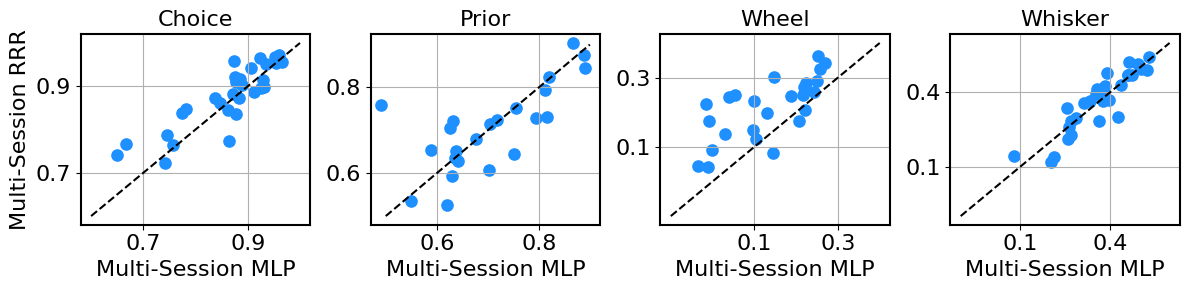

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(12, 3))

font_properties = {'fontsize': 12, 'fontweight': 'bold', 'family': 'serif'}

titles = ["Choice", "Prior", "Wheel", "Whisker"]
data = [(choice["mlp"], choice["reduced-rank"]), (prior["mlp"], prior["reduced-rank"]), (wheel["mlp"], wheel["reduced-rank"]), (whisker["mlp"], whisker["reduced-rank"])]
colors = ['dodgerblue', 'dodgerblue', 'dodgerblue', 'dodgerblue']

for ax_i, (ax, (x, y), title, color) in enumerate(zip(axes.flat, data, titles, colors)):
    ax.scatter(x, y, color='dodgerblue', s=65)

    if title == "Choice":
      ax.plot([0.6, 1.], [0.6, 1.], linestyle='--', color='black')
    elif title == "Prior":
      ax.plot([0.5, 0.9], [0.5, 0.9], linestyle='--', color='black')
    elif title == "Wheel":
      ax.plot([-0.1, 0.4], [-0.1, 0.4], linestyle='--', color='black')
    elif title == "Whisker":
      ax.plot([-0.1, 0.6], [-0.1, 0.6], linestyle='--', color='black')
    
    ax.set_title(title, fontsize=16)
    
    if ax_i == 0:
      ax.set_ylabel("Multi-Session RRR", fontsize=16)

    ax.set_xlabel("Multi-Session MLP", fontsize=16)
    ax.grid(True)

    if ax_i == 0:
      ax.set_xticks([0.70, 0.90])
      ax.set_yticks([0.70, 0.90])
    if ax_i == 1:
      ax.set_xticks([0.60, 0.80])
      ax.set_yticks([0.60, 0.80])
    if ax_i == 2:
      ax.set_xticks([0.1, 0.30])
      ax.set_yticks([0.1, 0.30])
    if ax_i == 3:
      ax.set_xticks([0.10, 0.40])
      ax.set_yticks([0.10, 0.40])

    for spine in ax.spines.values():
        spine.set_linewidth(1.5)

    ax.tick_params(axis='both', which='major', labelsize=16)
    ax.xaxis.set_major_formatter(plt.FormatStrFormatter('%.1f'))
    ax.yaxis.set_major_formatter(plt.FormatStrFormatter('%.1f'))

plt.tight_layout()
plt.savefig('/burg/stats/users/yz4123/neural_decoding/notebooks/figs/multi_session_mlp_comparison.png', dpi=400, bbox_inches='tight')
plt.show()

/local/ipykernel_3585686/996650573.py:40: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "orientation" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig('/burg/stats/users/yz4123/neural_decoding/notebooks/figs/multi_session_linear_comparison.png', dpi=400, bbox_inches='tight')
/local/ipykernel_3585686/996650573.py:40: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "facecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig('/burg/stats/users/yz4123/neural_decoding/notebooks/figs/multi_session_linear_comparison.png', dpi=400, bbox_inches='tight')
/local/ipykernel_3585686/996650573.py:40: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "edgecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig('/burg/stats/users/yz4123/neural_decoding/notebooks/figs/mult

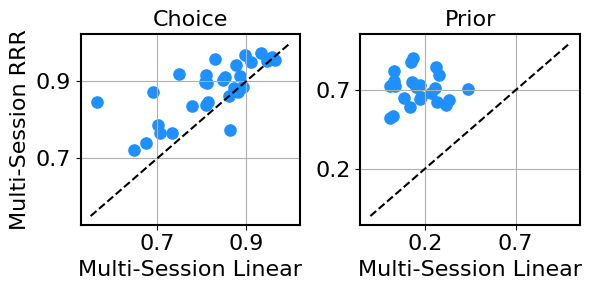

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(6, 3))

font_properties = {'fontsize': 12, 'fontweight': 'bold', 'family': 'serif'}

titles = ["Choice", "Prior"]
data = [(choice["full-rank"], choice["reduced-rank"]), (prior["full-rank"], prior["reduced-rank"])]
colors = ['dodgerblue', 'dodgerblue', 'dodgerblue', 'dodgerblue']

for ax_i, (ax, (x, y), title, color) in enumerate(zip(axes.flat, data, titles, colors)):
    ax.scatter(x, y, color='dodgerblue', s=65)
    
    if title == "Choice":
      ax.plot([0.55, 1.], [0.55, 1.], linestyle='--', color='black')
    elif title == "Prior":
      ax.plot([-0.1, 1.], [-0.1, 1.], linestyle='--', color='black')
    
    ax.set_title(title, fontsize=16)

    if ax_i == 0:
      ax.set_ylabel("Multi-Session RRR", fontsize=16)

    ax.set_xlabel("Multi-Session Linear", fontsize=16)
    ax.grid(True)

    if ax_i == 0:
      ax.set_xticks([0.70, 0.90])
      ax.set_yticks([0.70, 0.90])
    if ax_i == 1:
      ax.set_xticks([0.2, 0.70])
      ax.set_yticks([0.2, 0.70])

    for spine in ax.spines.values():
        spine.set_linewidth(1.5)

    ax.tick_params(axis='both', which='major', labelsize=16)
    ax.xaxis.set_major_formatter(plt.FormatStrFormatter('%.1f'))
    ax.yaxis.set_major_formatter(plt.FormatStrFormatter('%.1f'))

plt.tight_layout()
plt.savefig('/burg/stats/users/yz4123/neural_decoding/notebooks/figs/multi_session_linear_comparison.png', dpi=400, bbox_inches='tight')
plt.show()

In [22]:
(np.nanmean(wheel["reduced-rank"]) - np.nanmean(wheel["mlp"])) / np.nanmean(wheel["mlp"])



0.6016530882174123